In [103]:
import numpy as np, pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
from itertools import combinations
from cluster_lang2vec_distances import build_distance_matrix, auto_k, cluster_with_k
from lang2vec import lang2vec as l2v
from IPython.display import display, HTML
from sklearn.manifold import MDS
    

# load and filter, only select train split and no _removed subsets
df = pd.read_csv("/home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/base_data/fineweb2-language-distribution.csv")
df = df[(df.split == "train") & ~df.subset.str.contains("_removed$", na=False)]

# select top 200 languages by document count
top = (
    df.assign(documents=pd.to_numeric(df.documents, errors="coerce").fillna(0))
      .groupby(["code", "name", "family", "resource_availability"], as_index=False)
      ["documents"].sum()
      .sort_values("documents", ascending=False)
      .head(200)
)

langs = top[top.code.isin(l2v.DISTANCE_LANGUAGES)].reset_index(drop=True)
# keep only the dominant subset per language, problem was i was getting arb_Arab and arb_Latn for Arabic for example
langs = (
    langs.sort_values("documents", ascending=False)
         .drop_duplicates(subset="code", keep="first")
         .reset_index(drop=True)
)

codes = langs.code.tolist()
matrix = build_distance_matrix(codes, "genetic")

def select_expert_clusters(matrix, max_experts=4, min_cluster_size=3, k_min=None, k_max=60):
    if k_min is None:
        k_min = max_experts

    best_k, _ = auto_k(matrix, k_min, k_max, "average", min_cluster_size=min_cluster_size)
    labels = cluster_with_k(matrix, best_k, "average")

    clusters = {
        c: np.where(labels == c)[0]
        for c in np.unique(labels)
        if np.sum(labels == c) >= min_cluster_size
    }
    selected = [max(clusters, key=lambda c: len(clusters[c]))]

    while len(selected) < max_experts:
        remaining = [c for c in clusters if c not in selected]
        if not remaining:
            break

        next_c = max(
            remaining,
            key=lambda c: min(
                matrix[np.ix_(clusters[c], clusters[s])].mean()
                for s in selected
            )
        )
        selected.append(next_c)

    return selected, clusters

def extract_subgroups(indices, matrix, subgroup_size=3, max_subgroups=1):
    idx = list(indices)
    subgroups = []

    for _ in range(max_subgroups):
        if len(idx) < subgroup_size:
            break

        best = min(
            combinations(idx, subgroup_size),
            key=lambda t: np.mean([
                matrix[t[i], t[j]]
                for i in range(subgroup_size)
                for j in range(i+1, subgroup_size)
            ])
        )
        subgroups.append(list(best))
        idx = [i for i in idx if i not in best]

    return subgroups


def plot_selected_experts(matrix, codes, experts):
    # show in 2D using MDS and UMAP
    coords_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(matrix)
    coords_umap = umap.UMAP(metric="precomputed", random_state=0).fit_transform(matrix)

    _, ax = plt.subplots(1, 2, figsize=(12, 5))

    # background
    ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
    ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)

    # selected experts only
    for i, exp in enumerate(experts.values()):
        idx = [codes.index(c) for c in exp]

        ax[0].scatter(coords_mds[idx, 0], coords_mds[idx, 1],
                      s=70, label=f"Expert {i}")
        ax[1].scatter(coords_umap[idx, 0], coords_umap[idx, 1],
                      s=70, label=f"Expert {i}")

    ax[0].set_title("MDS – selected experts")
    ax[1].set_title("UMAP – selected experts")
    ax[0].legend()

    plt.tight_layout()
    plt.show()


def display_expert_config(experts, df, max_height=220):
    for i, langs in enumerate(experts.values()):
        info = (
            df[df.code.isin(langs)]
            [["code", "name", "family", "resource_availability", "subset"]]
            .drop_duplicates(subset="code")
            .sort_values("code")
        )
        display(HTML(f"<h4>Expert {i}</h4>"))
        display(HTML(info.to_html(index=False).replace("<table", f'<table style="display:block; max-height:{max_height}px; 'f'overflow-y:auto; width:100%"')))

code,name,family,resource_availability,subset
fur,Friulian,Indo-European,LOW,fur_Latn
roh,Romansh,Indo-European,LOW,roh_Latn
wln,Walloon,Indo-European,LOW,wln_Latn


code,name,family,resource_availability,subset
aeb,Tunisian Arabic,Afro-Asiatic,LOW,aeb_Arab
arb,Standard Arabic,Afro-Asiatic,HIGH,arb_Arab
mlt,Maltese,Afro-Asiatic,LOW,mlt_Latn


code,name,family,resource_availability,subset
ava,Avaric,Nakh-Daghestanian,LOW,ava_Cyrl
che,Chechen,Nakh-Daghestanian,LOW,che_Cyrl
inh,Ingush,Nakh-Daghestanian,LOW,inh_Cyrl


code,name,family,resource_availability,subset
nde,North Ndebele,Niger-Congo,LOW,nde_Latn
xho,Xhosa,Niger-Congo,LOW,xho_Latn
zul,Zulu,Niger-Congo,LOW,zul_Latn


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


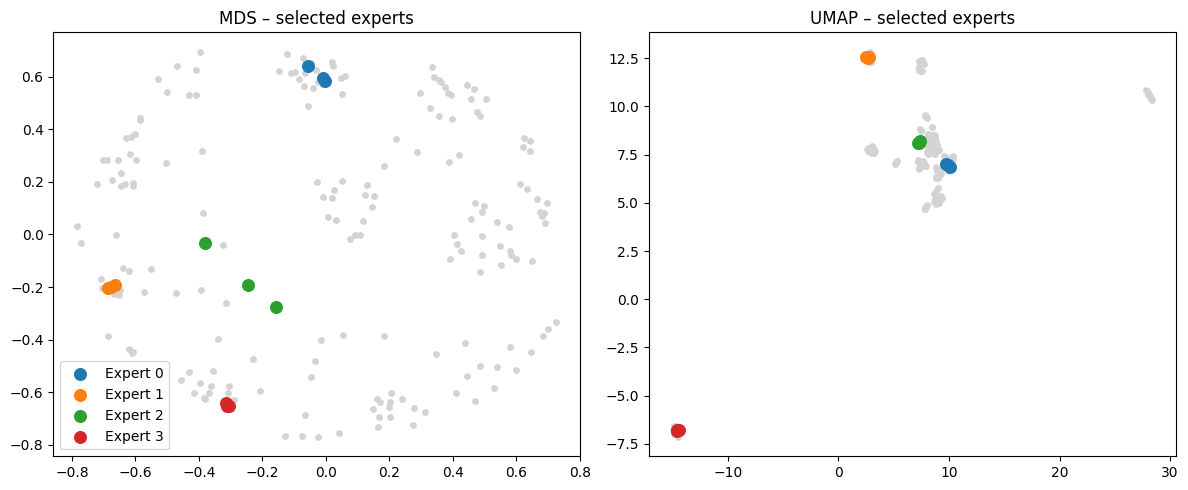

In [104]:
# for tier1 - 12 lang selection

expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=4,
    min_cluster_size=3
)

experts = {}
for c in expert_ids:
    subgroups = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=3,
        max_subgroups=1
    )
    experts[c] = [codes[i] for i in subgroups[0]]

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)



## 72 lang selection

code,name,family,resource_availability,subset
cat,Catalan,Indo-European,MEDIUM,cat_Latn
fur,Friulian,Indo-European,LOW,fur_Latn
glg,Galician,Indo-European,LOW,glg_Latn
ita,Italian,Indo-European,HIGH,ita_Latn
nap,Neapolitan,Indo-European,LOW,nap_Latn
pap,Papiamento,Creole,LOW,pap_Latn
roh,Romansh,Indo-European,LOW,roh_Latn
scn,Sicilian,Indo-European,LOW,scn_Latn
wln,Walloon,Indo-European,LOW,wln_Latn


code,name,family,resource_availability,subset
azb,South Azerbaijani,Turkic,LOW,azb_Arab
bak,Bashkir,Turkic,LOW,bak_Cyrl
kaz,Kazakh,Turkic,MEDIUM,kaz_Cyrl
kir,Kirghiz,Turkic,LOW,kir_Cyrl
lao,Lao,Kra-Dai,LOW,lao_Laoo
shn,Shan,Kra-Dai,LOW,shn_Mymr
tha,Thai,Kra-Dai,HIGH,tha_Thai
tuk,Turkmen,Turkic,NaN,tuk_Arab
uzn,Northern Uzbek,Turkic,NaN,uzn_Cyrl


code,name,family,resource_availability,subset
acm,Mesopotamian Arabic,Afro-Asiatic,LOW,acm_Arab
aeb,Tunisian Arabic,Afro-Asiatic,LOW,aeb_Arab
apc,Levantine Arabic,Afro-Asiatic,LOW,apc_Arab
arb,Standard Arabic,Afro-Asiatic,HIGH,arb_Arab
ars,Najdi Arabic,Afro-Asiatic,LOW,ars_Arab
ary,Moroccan Arabic,Afro-Asiatic,LOW,ary_Arab
hbo,Ancient Hebrew,Afro-Asiatic,LOW,hbo_Hebr
heb,Hebrew,Afro-Asiatic,HIGH,heb_Hebr
mlt,Maltese,Afro-Asiatic,LOW,mlt_Latn


code,name,family,resource_availability,subset
bod,Tibetan,Sino-Tibetan,LOW,bod_Tibt
dzo,Dzongkha,Sino-Tibetan,LOW,dzo_Tibt
kac,Kachin,Sino-Tibetan,LOW,kac_Latn
lus,Lushai,Sino-Tibetan,LOW,lus_Latn
mya,Burmese,Sino-Tibetan,LOW,mya_Mymr
new,Newari,Sino-Tibetan,LOW,new_Deva


code,name,family,resource_availability,subset
ava,Avaric,Nakh-Daghestanian,LOW,ava_Cyrl
che,Chechen,Nakh-Daghestanian,LOW,che_Cyrl
inh,Ingush,Nakh-Daghestanian,LOW,inh_Cyrl


code,name,family,resource_availability,subset
bcl,Central Bikol,Austronesian,LOW,bcl_Latn
bew,Betawi,Creole,LOW,bew_Latn
ceb,Cebuano,Austronesian,LOW,ceb_Latn
fij,Fijian,Austronesian,LOW,fij_Latn
hil,Hiligaynon,Austronesian,LOW,hil_Latn
ind,Indonesian,Austronesian,HIGH,ind_Latn
smo,Samoan,Austronesian,LOW,smo_Latn
ton,Tonga (Tonga Islands),Austronesian,LOW,ton_Latn
zsm,Standard Malay,Austronesian,NaN,zsm_Arab


code,name,family,resource_availability,subset
kin,Kinyarwanda,Niger-Congo,LOW,kin_Latn
lug,Ganda,Niger-Congo,LOW,lug_Latn
nde,North Ndebele,Niger-Congo,LOW,nde_Latn
nya,Nyanja,Niger-Congo,LOW,nya_Latn
run,Rundi,Niger-Congo,LOW,run_Latn
sot,Southern Sotho,Niger-Congo,LOW,sot_Latn
tso,Tsonga,Niger-Congo,LOW,tso_Latn
xho,Xhosa,Niger-Congo,LOW,xho_Latn
zul,Zulu,Niger-Congo,LOW,zul_Latn


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


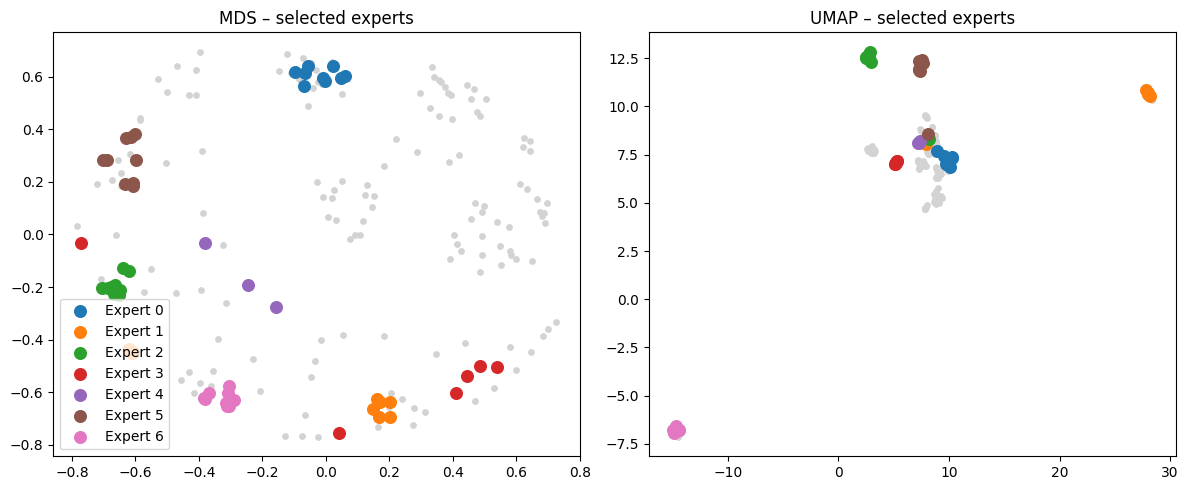

In [105]:
# target: ~72 langs → 8 experts × (3 subgroups × 3 langs)
expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=8,
    min_cluster_size=3,   # allow smaller families
)

experts = {}
for c in expert_ids:
    subs = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=3,
        max_subgroups=3
    )
    experts[c] = [codes[i] for sg in subs for i in sg]  # ~9 langs / expert

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)


## Important: subgroup selection
The expert subsets look very nice and as expected.
Now we continue to subgroup the langs within each expert, to determine in which B matrices the should be routed.
A important decision i made here: We dont force to have 3 B matrices, we subgroup all langs in one expert and let the amount of B matrices develop naturally based on the subclustering

In [ ]:
def subcluster_expert(exp_codes, codes, matrix, k_max=4,
                      min_subgroup_size=2, quality_threshold=0.9):
    import numpy as np

    idx = np.array([codes.index(c) for c in exp_codes])
    n = len(idx)

    if n < 2 * min_subgroup_size:
        return [exp_codes]

    subM = matrix[np.ix_(idx, idx)]
    baseline = np.mean([subM[i, j] for i in range(n) for j in range(i+1, n)])

    best_split, best_score = None, baseline

    for k in range(2, min(k_max, n // min_subgroup_size) + 1):
        labels = cluster_with_k(subM, k, "average")

        groups = {}
        for i, lab in enumerate(labels):
            groups.setdefault(lab, []).append(exp_codes[i])

        #only consider splits with ≥1 real subgroup
        if sum(len(g) >= min_subgroup_size for g in groups.values()) == 0:
            continue

        score = np.mean([
            matrix[codes.index(a), codes.index(b)]
            for g in groups.values() if len(g) >= min_subgroup_size
            for a in g for b in g if a < b
        ])

        if score < best_score * quality_threshold:
            best_split, best_score = list(groups.values()), score

    return best_split if best_split else [exp_codes]




def display_expert_subgroups(expert_subgroups, df, max_height=200):
    for e_idx, subgroups in expert_subgroups.items():
        display(HTML(f"<h3>Expert {e_idx}</h3>"))

        for sg_idx, sg_codes in enumerate(subgroups):
            # FIX: ensure list-like
            codes_list = sg_codes if isinstance(sg_codes, (list, tuple, set)) else [sg_codes]

            info = (
                df[df.code.isin(codes_list)]
                [["code", "name", "family", "resource_availability", "subset"]]
                .drop_duplicates(subset="code")
                .sort_values("code")
            )

            display(HTML(f"<b>Subgroup {sg_idx}</b>"))
            display(HTML(info.to_html(index=False).replace("<table", f'<table style="display:block; max-height:{max_height}px; ' f'overflow-y:auto; width:100%"')))
            
            
def plot_expert_subgroups(matrix, codes, expert_subgroups, method="umap"):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.manifold import MDS
    import umap.umap_ as umap

    n_experts = len(expert_subgroups)
    fig, axes = plt.subplots(1, n_experts, figsize=(4*n_experts, 4), squeeze=False)
    axes = axes[0]

    for e_idx, subgroups in expert_subgroups.items():
        # flatten expert languages
        exp_codes = [c for sg in subgroups for c in sg]
        idx = np.array([codes.index(c) for c in exp_codes])
        subM = matrix[np.ix_(idx, idx)]

        # embed
        n = subM.shape[0]
        if n < 4 or method == "mds":
            coords = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(subM)
        else:
            coords = umap.UMAP(metric="precomputed", n_neighbors=min(10, n-1), random_state=0).fit_transform(subM)

        ax = axes[e_idx]
        start = 0

        # plot each subgroup
        for sg_idx, sg in enumerate(subgroups):
            sg_len = len(sg)
            pts = coords[start:start + sg_len]
            ax.scatter(pts[:, 0], pts[:, 1], s=50, label=f"S{sg_idx}")
            start += sg_len

        ax.set_title(f"Expert {e_idx}")
        ax.axis("off")
        ax.legend(fontsize=8)

    fig.suptitle(f"Expert subgroups ({method.upper()})", y=1.05)
    plt.tight_layout()
    plt.show()

code,name,family,resource_availability,subset
roh,Romansh,Indo-European,LOW,roh_Latn


code,name,family,resource_availability,subset
fur,Friulian,Indo-European,LOW,fur_Latn


code,name,family,resource_availability,subset
wln,Walloon,Indo-European,LOW,wln_Latn


code,name,family,resource_availability,subset
cat,Catalan,Indo-European,MEDIUM,cat_Latn


code,name,family,resource_availability,subset
glg,Galician,Indo-European,LOW,glg_Latn


...

code,name,family,resource_availability,subset
lug,Ganda,Niger-Congo,LOW,lug_Latn


code,name,family,resource_availability,subset
nya,Nyanja,Niger-Congo,LOW,nya_Latn


code,name,family,resource_availability,subset
sot,Southern Sotho,Niger-Congo,LOW,sot_Latn


code,name,family,resource_availability,subset
tso,Tsonga,Niger-Congo,LOW,tso_Latn


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: U

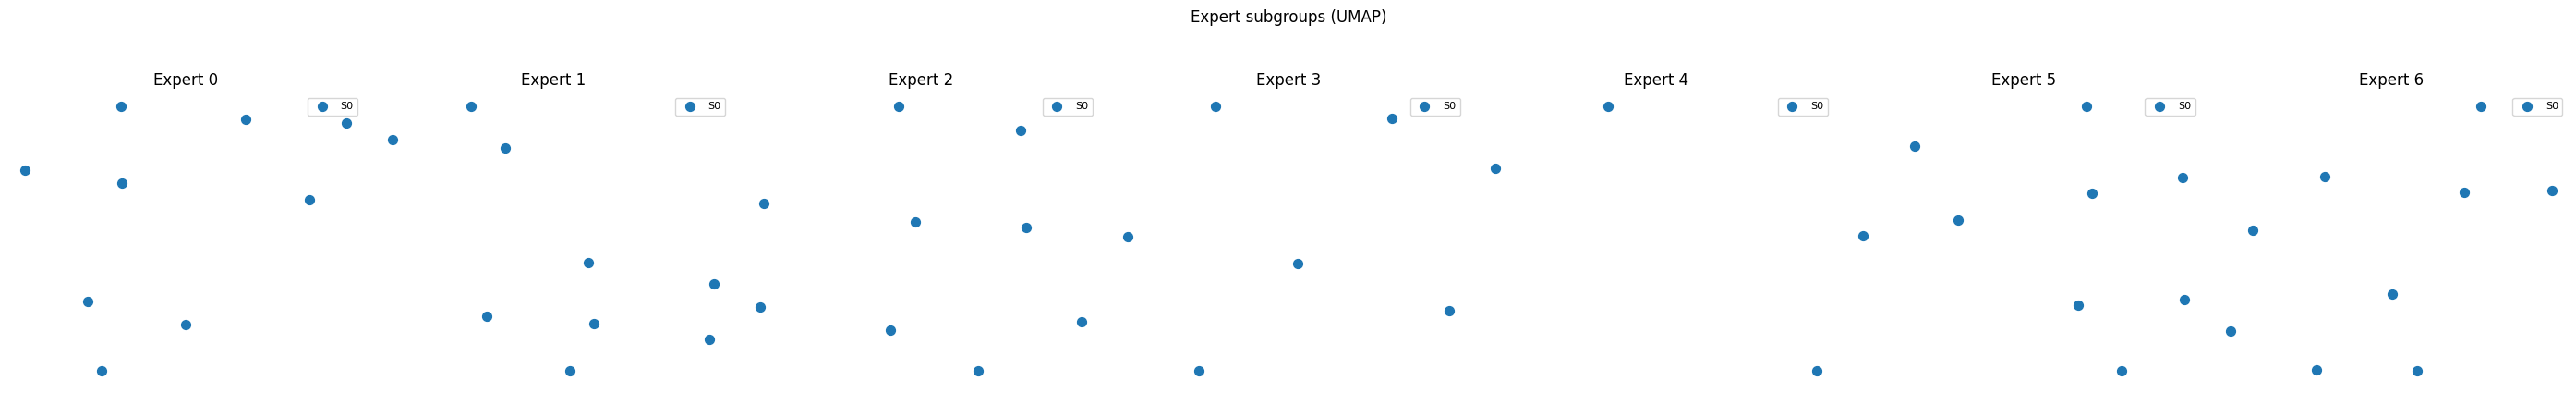

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.w

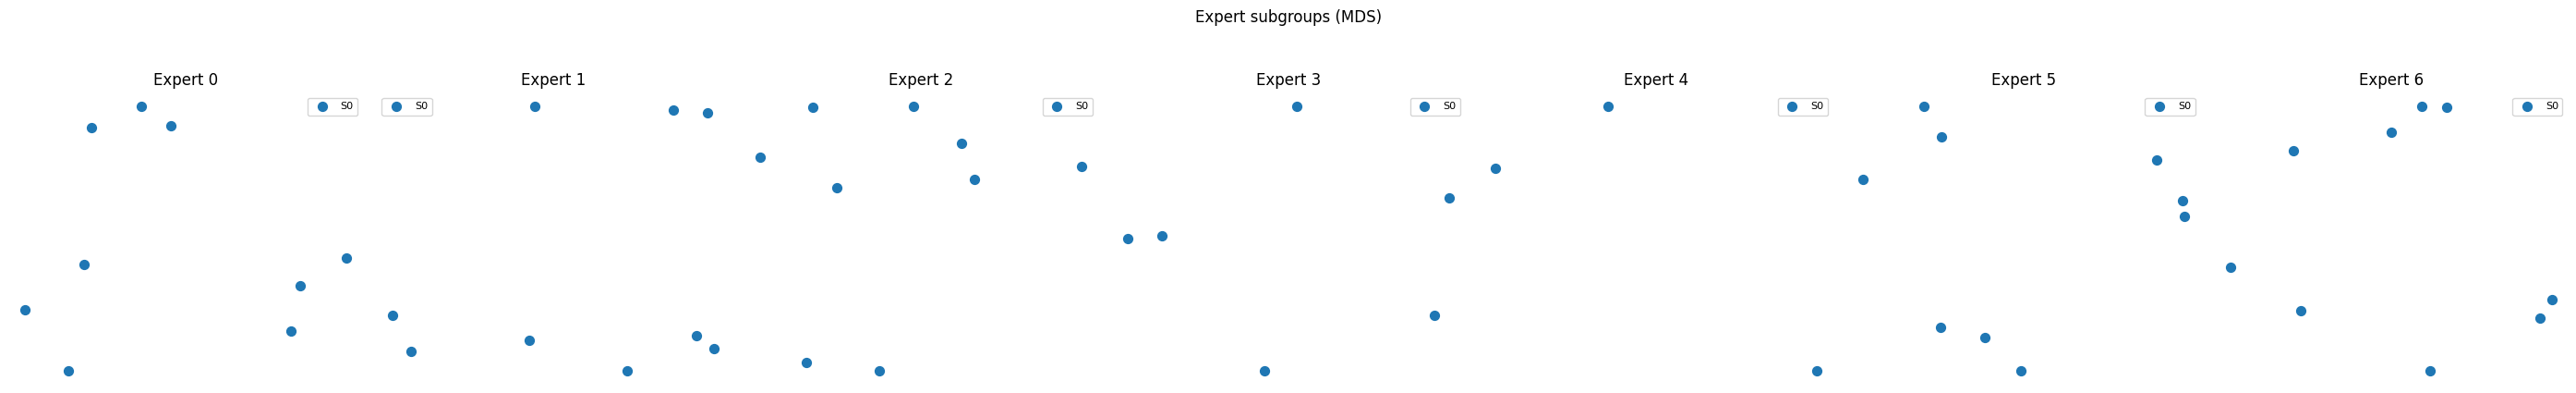

In [107]:
# build subgroups inside each expert
expert_subgroups = {}
for e_idx, exp_codes in enumerate(experts.values()):
    expert_subgroups[e_idx] = subcluster_expert(
        exp_codes,
        codes,
        matrix,
        k_max=4,
        min_subgroup_size=2,
        quality_threshold=0.2
    )

# inspect
display_expert_subgroups(experts, df)
# UMAP view
plot_expert_subgroups(matrix, codes, expert_subgroups, method="umap")

# MDS view
plot_expert_subgroups(matrix, codes, expert_subgroups, method="mds")



## 200 lang susbet

In [ ]:
expert_ids, clusters = select_expert_clusters(
    matrix,
    max_experts=16,
    min_cluster_size=12
)

# 4 subgroups × 4 langs = 16 langs / expert
experts = {}
for c in expert_ids:
    subs = extract_subgroups(
        clusters[c],
        matrix,
        subgroup_size=4,
        max_subgroups=4
    )
    experts[c] = [codes[i] for sg in subs for i in sg]

display_expert_config(experts, df)
plot_selected_experts(matrix, codes, experts)
